## Kernel truncation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from helper_functions import power_law_kernel, rayleigh_kernel, gaussian_kernel, sigmoid_kernel, exponential_kernel

In [2]:
T = 100
t_values = np.arange(T, 0, -1)

exp_params = [0.9, 0.5]

kernel_values_exp = exponential_kernel(exp_params, t_values, lag=1)

### Simulation with truncated kernel

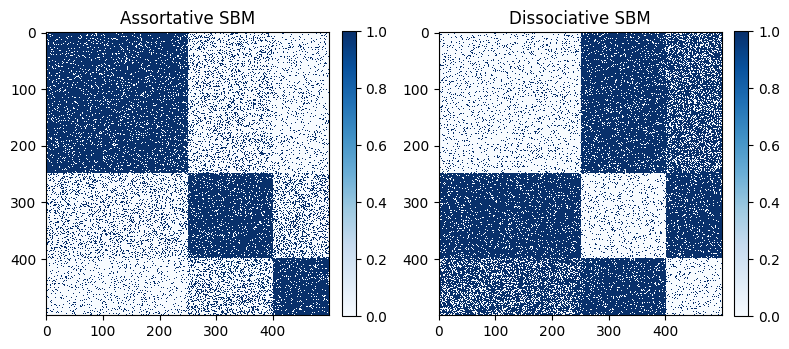

In [3]:
from simulation import simulate_comb_sbm, simulate_mf_sbm
from synthetic_data import generate_sbm_adjacency_matrix

In [4]:
# Three community example

final_time = 100
num_nodes1 = 500
num_nodes2 = 5000
alphas =  np.array([0.5,0.3,0.2]) 
comm_size1 = (num_nodes1 * alphas).astype(int)
comm_size2 = (num_nodes2 * alphas).astype(int)

#Assertative
prob_matrix = np.array([[0.9, 0.2, 0.1],
                               [0.2, 0.9, 0.3],
                               [0.1, 0.3, 0.9]])

power_params =  [0.9, 2.5]
ray_params = [0.5, 1.0]
exp_params = [0.9, 0.5]

kernel_params_matrix = np.array([exp_params, ray_params, power_params])
kernel_params_matrix = np.array([exp_params, ray_params, power_params])
kernel_function_matrix = np.array([exponential_kernel, rayleigh_kernel, power_law_kernel])

In [5]:
# ## Two community example

# alphas =  np.array([0.8, 0.2]) 
# comm_size1 = (num_nodes1 * alphas).astype(int)
# comm_size2 = (num_nodes2 * alphas).astype(int)

# #Assertative
# prob_matrix = np.array([[0.9, 0.1],
#                         [0.1, 0.9]])

In [6]:
power_params =  [0.9, 2.5]
ray_params = [0.5, 1.0]
exp_params = [0.9, 0.5]


# kernel_params_matrix = np.array([exp_params, ray_params, power_params])
# kernel_function_matrix = np.array([exponential_kernel, rayleigh_kernel, power_law_kernel])

kernel_params_matrix = np.array([exp_params, exp_params, exp_params])
kernel_function_matrix = np.array([exponential_kernel, exponential_kernel, exponential_kernel])


labs, adj_matrix = generate_sbm_adjacency_matrix(comm_size2, prob_matrix)
E = np.random.exponential(scale = 1.0, size = (final_time, num_nodes2, 100))
N_comb, lmbd_comb ,X_comb = simulate_comb_sbm(E, final_time,num_nodes2,comm_size2, kernel_function_matrix, kernel_params_matrix, adj_matrix, labs, mu_vector = np.array([0.9, 0.5, 0.3]), lag =1)

In [7]:
N_mf, lmbd_mf, X_mf, kernel_values = simulate_mf_sbm(E, final_time, comm_size2, prob_matrix, kernel_function_matrix, kernel_params_matrix,mu_vector = np.array([0.9, 0.5, 0.3]), lag =1)

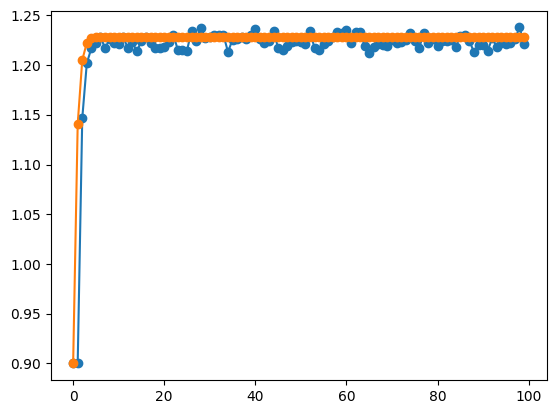

In [8]:
plt.plot(lmbd_comb[:,1], label='Community 1 - COMB', marker='o')
plt.plot(lmbd_mf[:,0], label='Community 1 - MF', marker = 'o')

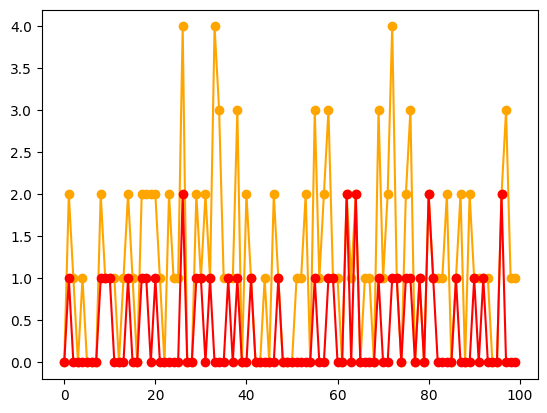

In [9]:
plt.plot(X_comb[:,5], label='Community 1 - COMB', marker='o', color = 'orange')
plt.plot(X_mf[:,5], label='Community 1 - MF', marker = 'o', color = 'red')

### Inference on the lagged data

In [10]:
from inference import jumps_per_community_over_time, lambda_bar_and_grad_for_all_times, loglik_approx, gradient_descent_fit, objective_and_grad, grad_loglik_fast, grad_loglik_intuitive

In [11]:
lag = 1
num_comm =len(alphas)

phi_community_one = np.array([
    [
        exponential_kernel(exp_params, t),
        exponential_kernel(exp_params, t),
        exponential_kernel(exp_params, t)
    ]
    for t in range(1, lag+1)
])

phi_true = np.repeat(phi_community_one[:, None, :], num_comm, axis=1)
mu_true = np.array([0.9, 0.5, 0.3])

mu0  = np.full(num_comm, 0.3)          # (num_comm,)
phi0 = np.random.uniform(
    0.0, 0.7,
    size=(lag, num_comm, num_comm)
)  

In [12]:
lambda_bar, grad_lambda_bar = lambda_bar_and_grad_for_all_times(
        mu_true, phi_true, alphas, prob_matrix, comm_size2, lag, final_time)

ValueError: operands could not be broadcast together with shapes (1,2) (1,3) 

In [ ]:
grad_loglik = grad_loglik_intuitive(labs, comm_size2, X_comb, lambda_bar, grad_lambda_bar)
print(grad_loglik)

[-67741.21133091  57957.09396767  67281.01679147 -35752.62987587
  -2641.51306679   -526.42900302   7303.02910772  10925.92244153
   1451.55646463   4185.06668965   4174.17122155   4991.07710109]


### Gradiendt descent fit

In [ ]:
mu_hat, phi_hat, mu_iterates, phi_iterates, loglik_hist = gradient_descent_fit(
   mu0, phi0, alphas, prob_matrix, comm_size2,
    lag, X_comb, labs,
    lr_mu=1e-6, lr_phi=1e-6, max_iter=1000
)

iter   20  loglik = 165941.230028
iter   40  loglik = 161529.563836
iter   60  loglik = 161331.229001
iter   80  loglik = 161351.476974
iter  100  loglik = 161383.415918
iter  120  loglik = 161415.992564
iter  140  loglik = 161448.598265
iter  160  loglik = 161481.178519
iter  180  loglik = 161513.706623
iter  200  loglik = 161546.155760
iter  220  loglik = 161578.497503
iter  240  loglik = 161610.701726
iter  260  loglik = 161642.736602
iter  280  loglik = 161674.568616
iter  300  loglik = 161706.162611
iter  320  loglik = 161737.481842
iter  340  loglik = 161768.488069
iter  360  loglik = 161799.141672
iter  380  loglik = 161829.401798
iter  400  loglik = 161859.226552
iter  420  loglik = 161888.573212
iter  440  loglik = 161917.398498
iter  460  loglik = 161945.658869
iter  480  loglik = 161973.310876
iter  500  loglik = 162000.311543
iter  520  loglik = 162026.618798
iter  540  loglik = 162052.191930
iter  560  loglik = 162076.992082
iter  580  loglik = 162100.982769
iter  600  log

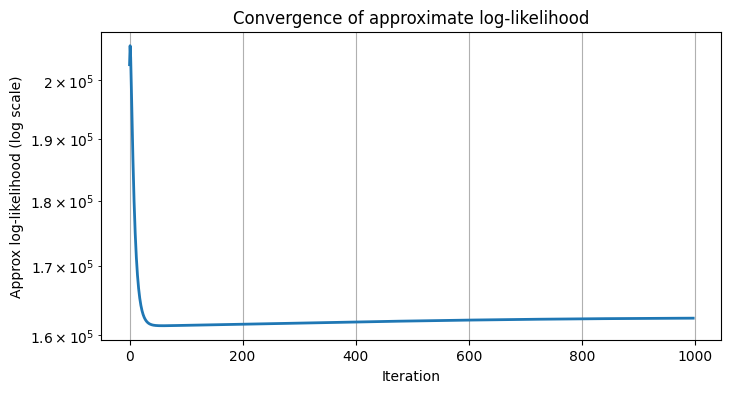

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(loglik_hist[2:], lw=2)
plt.yscale("log")   
plt.xlabel("Iteration")
plt.ylabel("Approx log-likelihood (log scale)")
plt.title("Convergence of approximate log-likelihood")
plt.grid(True)
plt.show()

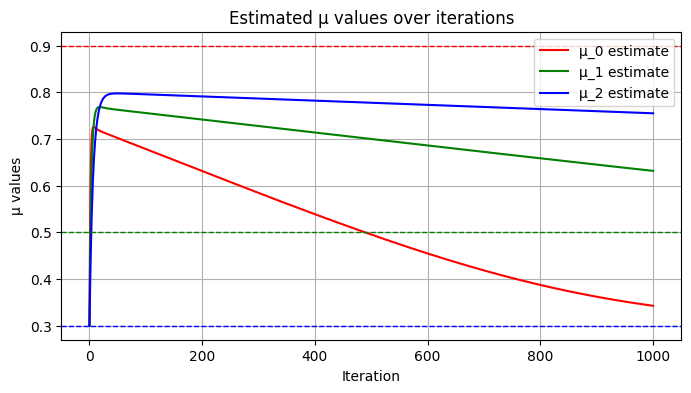

In [ ]:
colors = ['r', 'g', 'b']

plt.figure(figsize=(8,4))

for h in range(num_comm):
    plt.plot(mu_iterates[:, h], label=f"μ_{h} estimate", color=colors[h])

# plot true value as horizontal lines
for h in range(num_comm):
    plt.axhline(mu_true[h], color=colors[h], linestyle='--', linewidth=1)

plt.xlabel("Iteration")
plt.ylabel("μ values")
plt.title("Estimated μ values over iterations")
plt.legend()
plt.grid(True)
plt.show()


0.5458775937413701
0.5458775937413701
0.5458775937413701


/var/folders/dr/dsd8dmz50511xd_z7s87pr9m0000gp/T/ipykernel_20510/2642430151.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", num_comm * 2)


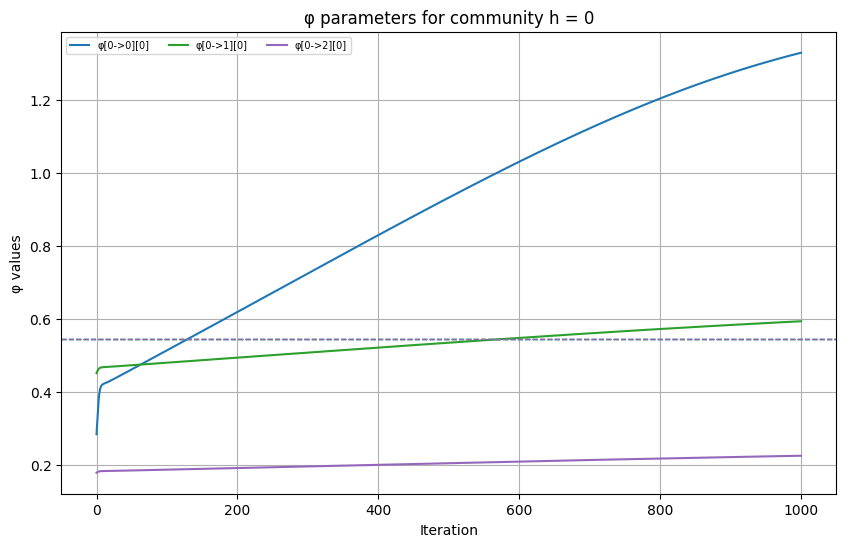

In [ ]:
h = 0
plt.figure(figsize=(10,6))

# get a colormap with enough distinct colors
cmap = plt.cm.get_cmap("tab20", num_comm * 2)

color_index = 0

for r in range(num_comm):
    for m in range(1):
        color = cmap(color_index)
        color_index += 1

        # estimated trajectory
        plt.plot(
            phi_iterates[:, m, h, r],
            label=f"φ[{h}->{r}][{m}]",
            color=color
        )

        # true value (same color, dashed)
        plt.axhline(
            phi_true[m, h, r],
            linestyle="--",
            linewidth=1,
            color=color
        )
        print(phi_true[m, h, r])

plt.xlabel("Iteration")
plt.ylabel("φ values")
plt.title(f"φ parameters for community h = {h}")
plt.legend(ncol=4, fontsize=7)
plt.grid(True)
plt.show()


### LBFGS fit

In [ ]:
# Combine parameters
params0 = np.concatenate([mu0.flatten(), phi0.flatten()])
n_mu = len(mu0.flatten())

def objective_for_optimizer(params):
    mu = params[:n_mu].reshape(mu0.shape)
    phi = params[n_mu:].reshape(phi0.shape)
    
    loglik, grad = objective_and_grad(mu, phi, alphas, prob_matrix, 
                                      comm_size2, lag, X_comb, labs)
    
    # L-BFGS minimizes, so return negative log-likelihood
    nll = -loglik
    grad_combined = -np.concatenate([grad[0].flatten(), grad[1].flatten()])
    
    return nll


In [ ]:
# Run L-BFGS
result = minimize(objective_for_optimizer, params0, method='L-BFGS-B', jac=False,
                  options={'maxiter': 1000})

# Extract results
mu_hat_optimizer = result.x[:n_mu].reshape(mu0.shape)
phi_hat_optimizer = result.x[n_mu:].reshape(phi0.shape)

/Users/jdm23/Documents/Studies/MSc/MScProjectExtenstion/poisson-autoregressions-on-large-network/src/inference.py:181: RuntimeWarning: overflow encountered in multiply
  lambda_bar[tau, h] = mu[h] + np.dot(alpha * prob_matrix[:, h], np.sum(phi[:tau, h, :][::-1, :] * lambda_bar[:tau, :] , axis=0))
/Users/jdm23/Documents/Studies/MSc/MScProjectExtenstion/poisson-autoregressions-on-large-network/src/inference.py:191: RuntimeWarning: overflow encountered in multiply
  rec = np.dot(alpha * prob_matrix[:, h], np.sum(phi[:tau, h, :][::-1, :] * grad_lambda_bar[:tau, :, r] , axis=0))
/Users/jdm23/Documents/Studies/MSc/MScProjectExtenstion/poisson-autoregressions-on-large-network/src/inference.py:212: RuntimeWarning: overflow encountered in multiply
  rec = np.dot(alpha * prob_matrix[:,h], np.sum(phi[:tau, h, :][::-1, :] * grad_lambda_bar[:tau, :, param_idx] , axis=0))
/Users/jdm23/Documents/Studies/MSc/MScProjectExtenstion/poisson-autoregressions-on-large-network/src/inference.py:181: RuntimeWar

In [ ]:
print(mu_hat_optimizer)
print(phi_hat_optimizer)

[-5.50027209 -7.57618581 -5.84800812]
[[[  21.25511313 -116.30471449  -55.81073105]
  [ 113.68977231  -26.18767712  -49.19726564]
  [ 174.2576388   -66.74625678   -8.21897127]]]


In [ ]:
colors = ['r', 'g', 'b']

plt.figure(figsize=(8,4))

for h in range(num_comm):
    plt.plot(mu_iterates[:, h], label=f"μ_{h} estimate", color=colors[h])

# plot true value as horizontal lines
for h in range(num_comm):
    plt.axhline(mu_true[h], color=colors[h], linestyle='--', linewidth=1)

plt.xlabel("Iteration")
plt.ylabel("μ values")
plt.title("Estimated μ values over iterations")
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'plt' is not defined

In [ ]:
phi_hat_lbfgs

NameError: name 'phi_hat_lbfgs' is not defined